In [1]:
import pandas as pd

df = pd.read_csv(r"../data/cluster_data.csv")

df.head()

,passes,shots,average_pass_length,ppda,avg_pass_angle_deep,avg_pass_angle_mid,avg_pass_angle_final,xg_per_shot,carries_per_pass,cluster,playstyle
0,537,11,20.786734,3.128655,-0.042155,-0.046114,-0.023094,0.098427,0.769088,1,Vertical
1,659,19,21.512906,2.338624,-0.034995,-0.128787,1.816389,0.052009,0.799697,4,Tiki-Taka
2,378,19,21.140958,2.108844,-0.107044,0.033943,-0.629554,0.326595,0.759259,0,Clinical Transition Play
3,365,16,23.869265,1.385417,-0.124896,0.032662,0.152638,0.290652,0.794521,0,Clinical Transition Play
4,460,11,21.812680,1.252688,-0.147674,-0.093207,-0.566419,0.068597,0.791304,1,Vertical


In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop(columns=["cluster", "playstyle"])
y = df["playstyle"]

In [4]:
x_train, x_validation, y_train, y_validation = train_test_split(X, y, test_size=0.3)\

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_validation_scaled = scaler.fit_transform(x_validation)

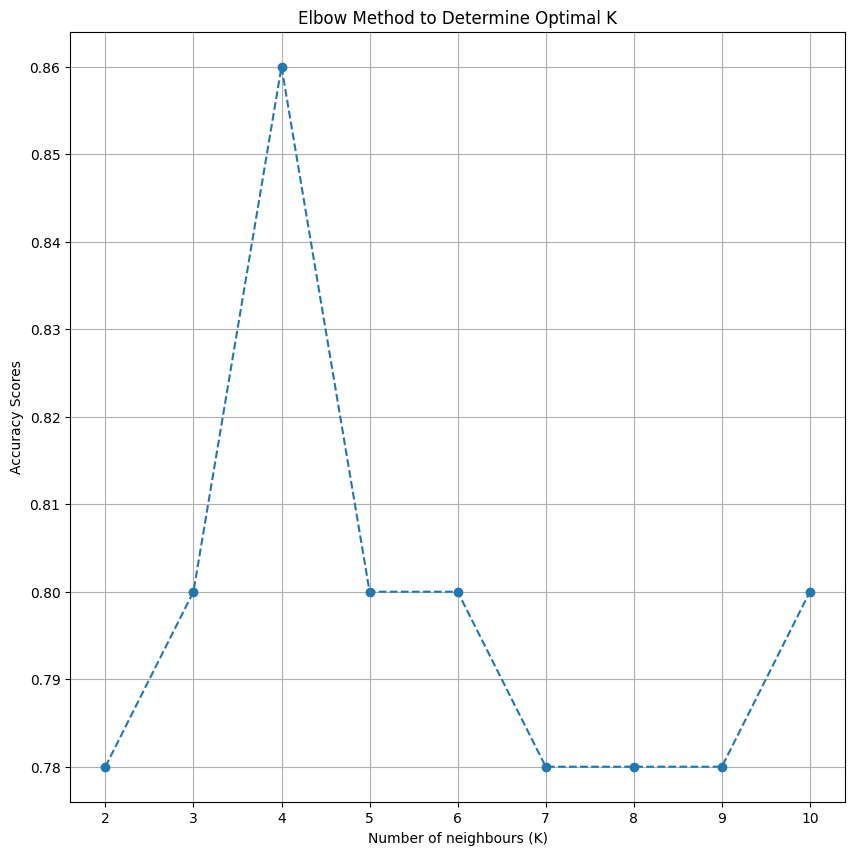

In [6]:
from sklearn.metrics import accuracy_score

acc = []
k_range = range(2, 11)

for k in k_range:
    k_classifier = KNeighborsClassifier(n_neighbors=k)
    k_classifier.fit(x_train_scaled, y_train)
    y_pred = k_classifier.predict(x_validation_scaled)
    acc.append(accuracy_score(y_validation, y_pred))

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.plot(k_range, acc, marker='o', linestyle='--')
plt.xlabel("Number of neighbours (K)")
plt.ylabel("Accuracy Scores")
plt.title("Elbow Method to Determine Optimal K")
plt.grid(True)
plt.show()

optimal value of k:

**k = 4**

In [14]:
from sklearn.metrics import classification_report

k_classifier = KNeighborsClassifier(n_neighbors=4)
k_classifier.fit(x_train_scaled, y_train)
y_pred = k_classifier.predict(x_validation_scaled)
print(accuracy_score(y_validation, y_pred))
print(classification_report(y_validation, y_pred))

0.86
                          precision    recall  f1-score   support

Clinical Transition Play       1.00      1.00      1.00         2
               Haramball       1.00      0.88      0.93        16
       Possessional Play       0.94      0.88      0.91        17
               Tiki-Taka       1.00      0.75      0.86        12
                Vertical       0.33      1.00      0.50         3

                accuracy                           0.86        50
               macro avg       0.85      0.90      0.84        50
            weighted avg       0.94      0.86      0.88        50



In [9]:
import joblib

joblib.dump(k_classifier, "../models/knn_classifier.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

Now let us try random forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(x_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_pred = model.predict(x_validation_scaled)

print("Accuracy:", accuracy_score(y_validation, y_pred))
print(classification_report(y_validation, y_pred))

Accuracy: 0.82
                          precision    recall  f1-score   support

Clinical Transition Play       1.00      1.00      1.00         2
               Haramball       0.88      0.88      0.88        16
       Possessional Play       0.78      0.82      0.80        17
               Tiki-Taka       1.00      0.67      0.80        12
                Vertical       0.50      1.00      0.67         3

                accuracy                           0.82        50
               macro avg       0.83      0.87      0.83        50
            weighted avg       0.85      0.82      0.82        50



KNN outperformed Random Forest by a significant margin. But we will still keep the Random Forest Model

In [18]:
importance = pd.Series(
    model.feature_importances_,
    index= x_train.columns
).sort_values(ascending=False)

importance

average_pass_length     0.192693
avg_pass_angle_deep     0.186076
passes                  0.170244
carries_per_pass        0.116068
xg_per_shot             0.110767
avg_pass_angle_final    0.072734
shots                   0.068137
avg_pass_angle_mid      0.041774
ppda                    0.041507
dtype: float64

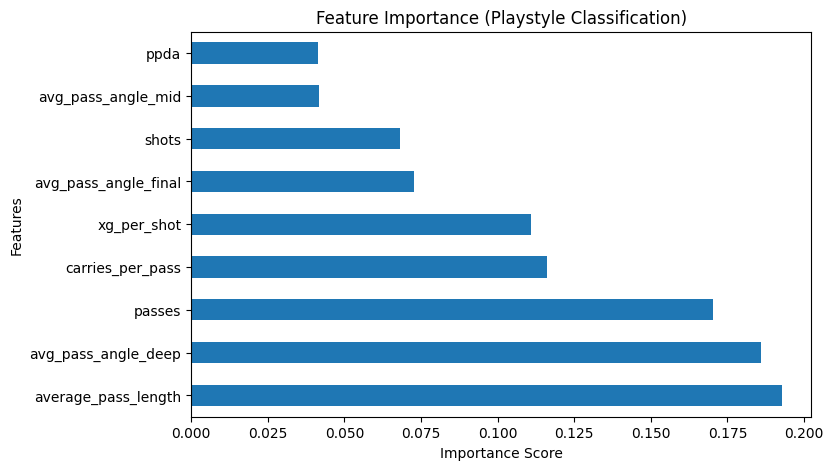

In [22]:
plt.figure(figsize=(8,5))
importance.plot(kind="barh")

plt.title("Feature Importance (Playstyle Classification)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [15]:
joblib.dump(model, "../models/random_forest_classifier.pkl")

['../models/random_forest_classifier.pkl']